# A2 — Knowledge-Base Demo (fill this)
Show OCR quality on a sample and one working retrieval example.

In [3]:

from pathlib import Path
import sys
import os

REPO_DIR = Path.cwd().parent

SRC_DIR = REPO_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(REPO_DIR)

from doc_agent import config, pipeline
from doc_agent.retrieval.retriever import Retriever

print(f"Repository: {REPO_DIR}")
print(f"Python: {sys.executable}")
print(f"Working directory: {Path.cwd()}")

Repository: f:\DL_project\doc-agent-G04
Python: f:\DL_project\doc-agent-G04\.venv\Scripts\python.exe
Working directory: f:\DL_project\doc-agent-G04


In [4]:
cfg = config.load()

print("Configuration loaded.")
print("OCR backend:", cfg["ocr"].get("backend"))
print("Embedding model:", cfg["embed"].get("model"))
print("Index type:", cfg["index"].get("type"))

Configuration loaded.
OCR backend: tesseract
Embedding model: sentence-transformers/all-MiniLM-L6-v2
Index type: faiss:flat-ip


In [6]:
print("Building knowledge base...")

pipeline.build_knowledge_base(cfg)

print("Knowledge-base build completed.")

Building knowledge base...
starting
Pages loaded
Pages pre processed
Pages enhanced
Regions detected
[Chunk(id='secondary_bv_2026_class_9_10_math__page_0002__region_0000', doc_id='secondary_bv_2026_class_9_10_math', text='| (5\n| B\n| =\n| SD\n| on\n| রণ', page_ids=['secondary_bv_2026_class_9_10_math__page_0002'], score=0.0), Chunk(id='secondary_bv_2026_class_9_10_math__page_0004__region_0000', doc_id='secondary_bv_2026_class_9_10_math', text='প্রসঙ্গকথা\nপ্রাতিষ্ঠানিক শিক্ষার উপযোগ বহুমাত্রিক। শুধু জ্ঞান পরিবেশন নয়, দক্ষ মানবসম্পদ গড়ে তোলার মাধ্যমে\nসমৃদ্ধ জাতিগঠন এই শিক্ষার মূল উদ্দেশ্য। একই সাথে মানবিক ও বিজ্ঞানমনস্ক সমাজগঠন নিশ্চিত করার\nপ্রধান অবলম্বনও প্রাতিষ্ঠানিক শিক্ষা বর্তমান বিজ্ঞান ও প্রযুক্তিনির্ভর বিশ্বে জাতি হিসেবে মাথা তুলে দাঁড়াতে\nহলে আমাদের মানসম্মত শিক্ষা নিশ্চিত করা প্রয়োজন | এর পাশাপাশি শিক্ষার্থীদের দেশপ্রেম, মূল্যবোধ ও\nনৈতিকতার শক্তিতে উজ্জীবিত করে তোলাও জরুরি |\nশিক্ষা জাতির মেরুদণ্ড আর প্রাতিষ্ঠানিক শিক্ষার প্রাণ শিক্ষাক্রম | শিক্ষাক্রম বাস্তবায়নের সবচেয

f:\DL_project\doc-agent-G04\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\DL_project\doc-agent-G04\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[[ 0.          0.          0.         ...  0.          0.
   0.15430336]
 [ 0.          0.03615507  0.         ...  0.          0.03615507
  -0.03615507]
 [ 0.07761505  0.          0.         ...  0.         -0.07761505
  -0.07761505]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.05198753  0.          0.05198753 ...  0.         -0.05198753
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
Entering store
Knowledge-base build completed.


In [11]:
raw_path = (
    REPO_DIR
    / "data"
    / "raw"
    / "secondary_bv_2026_class_9_10_math"
    / "page_0014.jpg"
)

preprocessed_path = (
    REPO_DIR
    / "data"
    / "interim"
    / "preprocessed"
    / "secondary_bv_2026_class_9_10_math"
    / "page_0014.png"
)

layout_path = (
    REPO_DIR
    / "reports"
    / "figures"
    / "layout"
    / "secondary_bv_2026_class_9_10_math"
    / "page_0014.png"
)

for path in [raw_path, preprocessed_path, layout_path]:
    print(path)
    print("exists:", path.is_file())
    print()

f:\DL_project\doc-agent-G04\data\raw\secondary_bv_2026_class_9_10_math\page_0014.jpg
exists: True

f:\DL_project\doc-agent-G04\data\interim\preprocessed\secondary_bv_2026_class_9_10_math\page_0014.png
exists: True

f:\DL_project\doc-agent-G04\reports\figures\layout\secondary_bv_2026_class_9_10_math\page_0014.png
exists: True



Original page size: (2175, 2850)


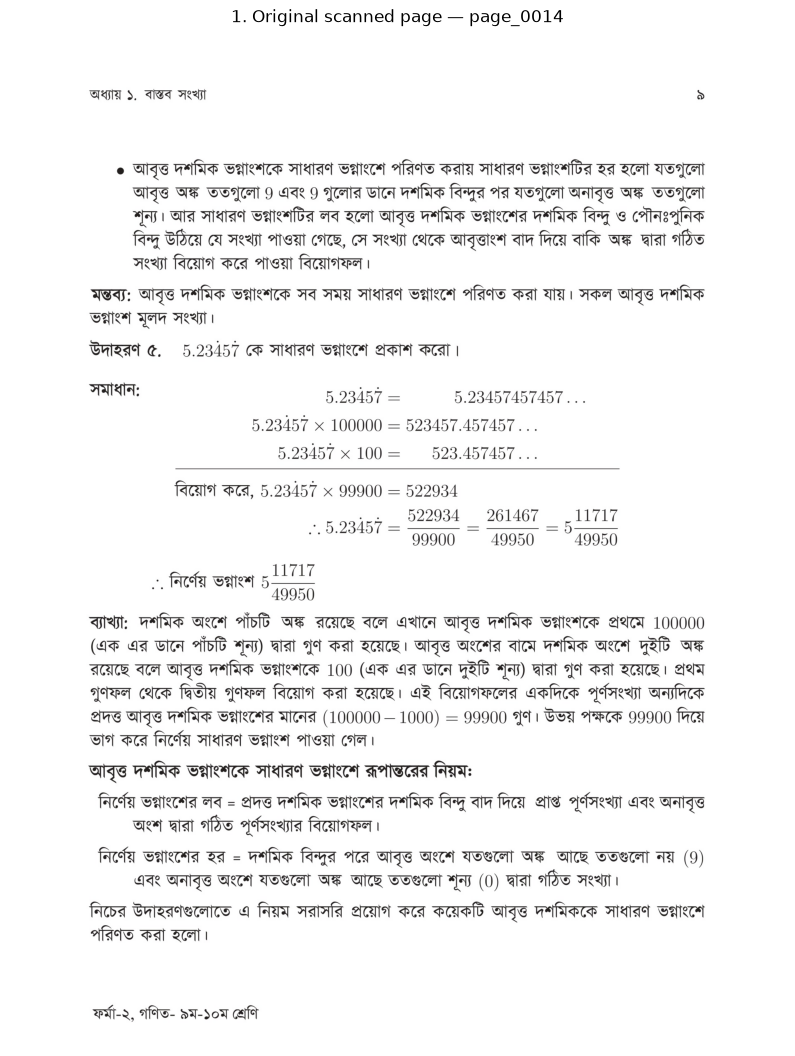

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
raw_image = Image.open(raw_path)

print("Original page size:", raw_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(raw_image)
plt.axis("off")
plt.title("1. Original scanned page — page_0014")
plt.show()

Preprocessed page size: (2175, 2850)


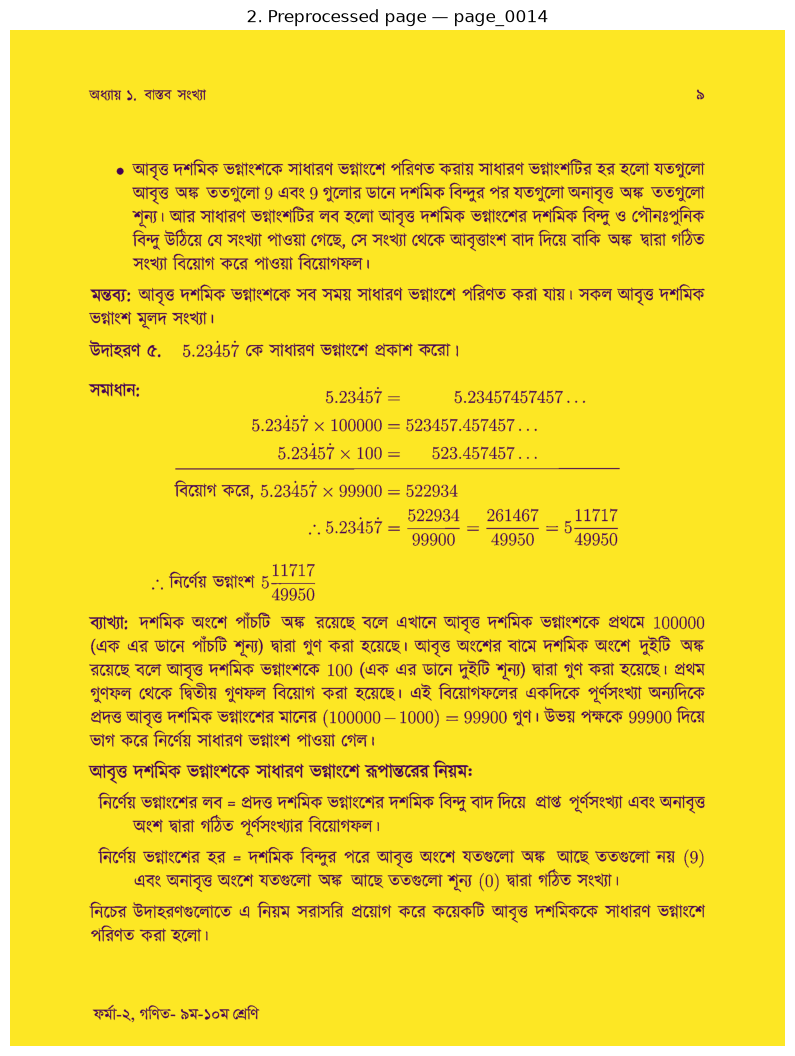

In [14]:
preprocessed_image = Image.open(preprocessed_path)

print("Preprocessed page size:", preprocessed_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_image)
plt.axis("off")
plt.title("2. Preprocessed page — page_0014")
plt.show()

Layout visualization size: (2175, 2850)


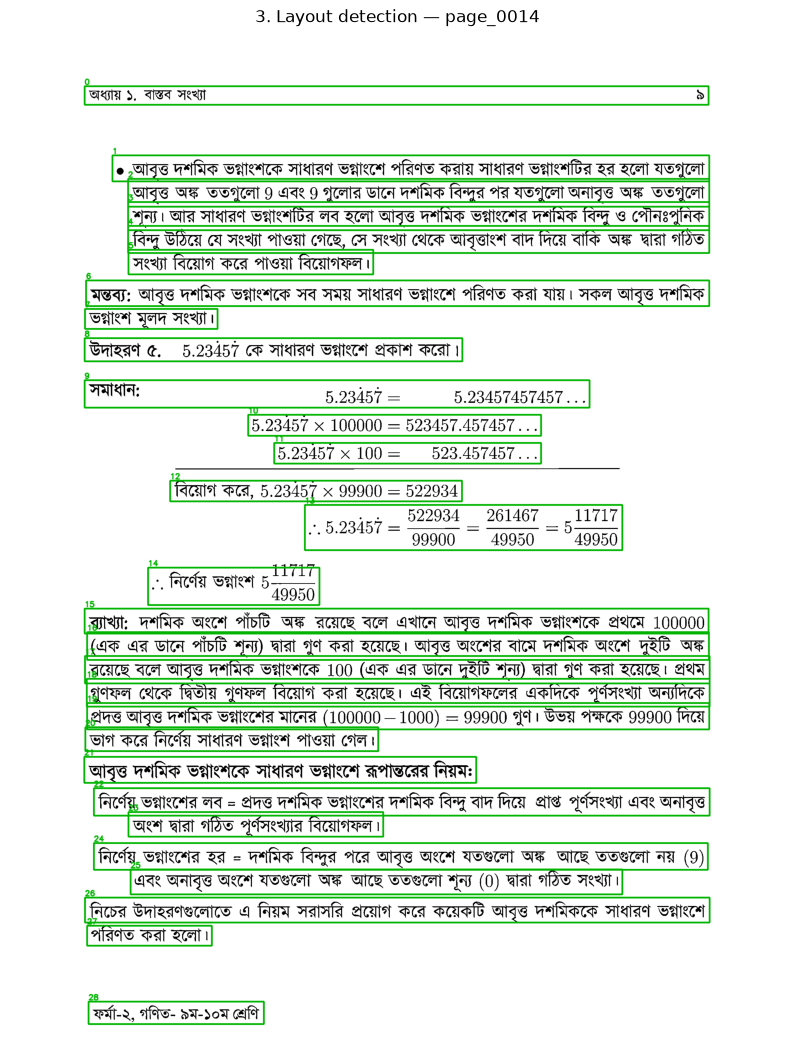

In [15]:
layout_image = Image.open(layout_path)

print("Layout visualization size:", layout_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(layout_image)
plt.axis("off")
plt.title("3. Layout detection — page_0014")
plt.show()

In [20]:
from doc_agent.contracts import Page
from doc_agent.vision import layout

page = Page(
    id="secondary_bv_2026_class_9_10_math__page_0014",
    image_path=str(preprocessed_path),
    doc_id="secondary_bv_2026_class_9_10_math",
)

regions = layout.detect([page], cfg)

print(f"Detected {len(regions)} regions on page_0014")
for i, region in enumerate(regions[:10]):
    print(i, region.page_id, region.kind, region.bbox)


Detected 29 regions on page_0014
0 secondary_bv_2026_class_9_10_math__page_0014 text (209, 156, 1751, 52)
1 secondary_bv_2026_class_9_10_math__page_0014 text (287, 350, 1675, 73)
2 secondary_bv_2026_class_9_10_math__page_0014 text (331, 416, 1631, 78)
3 secondary_bv_2026_class_9_10_math__page_0014 text (331, 481, 1631, 79)
4 secondary_bv_2026_class_9_10_math__page_0014 text (331, 548, 1631, 76)
5 secondary_bv_2026_class_9_10_math__page_0014 text (332, 615, 687, 69)
6 secondary_bv_2026_class_9_10_math__page_0014 text (213, 701, 1749, 72)
7 secondary_bv_2026_class_9_10_math__page_0014 text (210, 781, 372, 56)
8 secondary_bv_2026_class_9_10_math__page_0014 text (209, 863, 1060, 65)
9 secondary_bv_2026_class_9_10_math__page_0014 text (209, 981, 1417, 77)


In [21]:
from doc_agent.vision import ocr

reader = ocr.Reader(cfg)
ocr_results = []

for i, region in enumerate(regions):
    if region.kind not in {"text", "heading"}:
        continue

    text = reader.transcribe_region(region)
    if text:
        ocr_results.append(
            {
                "region_index": i,
                "kind": region.kind,
                "bbox": region.bbox,
                "text": text,
            }
        )

print(f"OCR extracted text from {len(ocr_results)} regions.")
for item in ocr_results[:5]:
    print(f"\n[{item['region_index']}] {item['kind']} {item['bbox']}")
    print(item['text'][:400])
    print("-" * 80)


OCR extracted text from 29 regions.

[0] text (209, 156, 1751, 52)
অধ্যায় ১. বাস্তব সংখ্যা ৯
--------------------------------------------------------------------------------

[1] text (287, 350, 1675, 73)
* আবৃত্ত দশমিক ভগ্নাংশকে সাধারণ ভগ্নাংশে পরিণত করায় সাধারণ ভগ্নাংশটির হর হলো যতগুলো
--------------------------------------------------------------------------------

[2] text (331, 416, 1631, 78)
আবৃত্ত অঙ্ক ততগুলো 9 এবং 9 গুলোর ডানে দশমিক বিন্দুর পর যতগুলো অনাবৃত্ত অঙ্ক ততগুলো
--------------------------------------------------------------------------------

[3] text (331, 481, 1631, 79)
শূন্য। আর সাধারণ ভগ্নাংশটির লব হলো আবৃত্ত দশমিক ভগ্নাংশের দশমিক বিন্দু ও পৌনঃপুনিক
--------------------------------------------------------------------------------

[4] text (331, 548, 1631, 76)
বিন্দু উঠিয়ে যে সংখ্যা পাওয়া গেছে, সে সংখ্যা থেকে আবৃত্তাংশ বাদ দিয়ে বাকি অঙ্ক দ্বারা গঠিত
--------------------------------------------------------------------------------


In [7]:
from doc_agent import pipeline

# Run the earlier stages again only if your pipeline exposes
# intermediate OCR output. Otherwise, inspect the generated
# preprocessed/OCR artifacts according to your project structure.

print("OCR backend:", cfg["ocr"].get("backend"))
print("OCR model/language:", cfg["ocr"].get("languages", cfg["ocr"].get("model")))

OCR backend: tesseract
OCR model/language: ben+eng


In [8]:
from doc_agent.vision import ocr
from doc_agent import contracts

print("OCR implementation loaded:")
print(ocr.Reader)

OCR implementation loaded:
<class 'doc_agent.vision.ocr.Reader'>


In [9]:
retriever = Retriever(cfg)

query = "বাস্তব সংখ্যা, সেট এবং ফাংশন সম্পর্কিত ধারণা"

results = retriever.retrieve(query, k=3)

print(f"Query: {query}")
print(f"Retrieved {len(results)} results\n")

for rank, hit in enumerate(results, start=1):
    page = hit.page_ids[0] if hit.page_ids else "unknown"

    print(f"#{rank}")
    print(f"Score: {hit.score:.3f}")
    print(f"Page:  {page}")
    print(f"ID:    {hit.id}")
    print("-" * 70)
    print(hit.text)
    print("=" * 70)

Query: বাস্তব সংখ্যা, সেট এবং ফাংশন সম্পর্কিত ধারণা
Retrieved 3 results

#1
Score: 0.261
Page:  secondary_bv_2026_class_9_10_math__page_0032
ID:    secondary_bv_2026_class_9_10_math__page_0032__region_0000__chunk_0000
----------------------------------------------------------------------
অধ্যায় ২, সেট ও ফাংশন ২৭ B অথবা A Union 1 সেট গঠন পদ্ধতিতে AUB - (৫ : ৫ 6 4 অথবা ৫ ০৪) । উদাহরণ ৮. 0০ -(3,4,5) এবং D = {4,6,8} হলে, 0 (1 নির্ণয় করো। C71 সমাধান: দেওয়া আছে, 0 = (3,4, 5) /3 /7 ৬১ 6৬ এবং D = {4,6,8} ( (4) | :. 0017-(,45) 0 (4,6,8) = {3,4,5,6,8} 5 \/ 8/ নির্ণেয় সেট: {3,4,5,6,8) জপ Tn ছেদ সেট (Intersection of Sets) দুই বা ততোধিক সেটের সাধারণ উপাদান নিয়ে গঠিত সেটকে ছেদ সেট IT মনে করি, 4 ও B দুইটি সেট । A ও এর ছেদ সেটকে AN B দ্বারা প্রকাশ করা হয় এবং পড়া হয় A ছেদ বা A intersection B 1 সেট গঠন পদ্ধতিতে 1073 - (৫: ৫ 5 AR z ০৪) । নিউ পে ত্বকে ক ANB ANnBNC উদাহরণ ৯, P={zeN:2<z<6} এবং 0 ল (৫ 5৮ :৫ জোড় সংখ্যা এবং ৫ < 8} হলে, 77 0 নির্ণয় করো। 9 -(৫ 54 :2 জোড় সংখ্যা এবং ৪ € 8] ={2468 \5 ৩৩/

In [10]:
query = "বাস্তব সংখ্যা, মূলদ ও অমূলদ সংখ্যা এবং দশমিক সংখ্যার আসন্ন মান"

results = retriever.retrieve(query, k=3)

for rank, hit in enumerate(results, start=1):
    page = hit.page_ids[0] if hit.page_ids else "unknown"

    print(f"\n#{rank} | score={hit.score:.3f} | page={page}")
    print(hit.text)
    print("-" * 80)


#1 | score=0.390 | page=secondary_bv_2026_class_9_10_math__page_0010
অধ্যায় ১. বাস্তব সংখ্যা ৫ . 20 এবং Lo সমান হতে পারে না, অর্থাৎ 207 7- . “5 কে ? আকারে প্রকাশ করা যাবে না, অর্থাৎ 427” . -. 2 একটি অমূলদ সংখ্যা | কাজ: ১. প্রমাণ কর যে, /3 একটি অমূলদ FRA | | ২. প্রমাণ কর যে, 6 একটি অমূলদ IR | | উদাহরণ ২. প্রমাণ কর যে, কোনো চারটি ক্রমিক স্বাভাবিক সংখ্যার গুণফলের সাথে 1 যোগ করলে যোগফল একটি পূর্ণবর্গ সংখ্যা হবে। সমাধান: মনে করি, চারটি ক্রমিক স্বাভাবিক সংখ্যা যথাক্রমে ৫, 71, ৫472, 2731 Gi সংখ্যা চারটির গুণফলের সাথে 1 যোগ করলে পাওয়া যায়, 2(৫-771)(2 7 2)(2 43) +1 =z(z+3)(z+1)(z+2)+1 = (৫১7 32)(৫২ 73৫ 72) +1 = ৫(৫ 472) +1 [এবার 2? + 3z = a ধরে] =a’+2a+1=(a+1)> = (2247 3x + 1)? যা একটি পূর্ণবর্গ সংখ্যা। সুতরাং যে কোনো চারটি ক্রমিক স্বাভাবিক সংখ্যার গুণফলের সাথে 1 যোগ করলে যোগফল একটি পূর্ণবর্গ সংখ্যা হবে। দশমিক ভথ্নাংশ (Decimal Fractions) আমরা জানি, প্রত্যেক বাস্তব সংখ্যাকে দশমিক ভগ্নাংশে প্রকাশ করা যায়। যেমন 2 = 2. 0, = = 0. 4, = 0. 333. ইত্যাদি। দশমিক ভগ্নাংশ তিন প্রকার: সসীম, আবৃত্ত এবং 